# Εργαστηριο Αναλυσης Ηλεκτροκαρδιογραφηματος (ECG)

## Βιοιατρικα Σηματα & Εφαρμογες

---

### Τι ειναι αυτο το εργαστηριο;

Σε αυτο το εργαστηριο θα δουλεψουμε με **πραγματικα δεδομενα** 
ηλεκτροκαρδιογραφηματος (ECG) απο τη βαση δεδομενων MIT-BIH 
του PhysioNet. Αυτη η βαση περιεχει καταγραφες απο πραγματικους 
ασθενεις και εχει χρησιμοποιηθει σε χιλιαδες ερευνητικες εργασιες 
παγκοσμιως.

Θα μαθουμε πως να:
- Φορτωνουμε και να βλεπουμε ενα ECG σημα
- Καθαριζουμε τον θορυβο με ψηφιακα φιλτρα
- Εντοπιζουμε τους καρδιακους παλμους αυτοματα
- Υπολογιζουμε τον καρδιακο ρυθμο (Heart Rate)
- Μετραμε τη μεταβλητοτητα του ρυθμου (HRV)
- Αναγνωριζουμε απλες αρρυθμιες

### Πως θα δουλεψουμε;

Θα χωριστουμε σε **3 ομαδες**. Καθε ομαδα θα αναλυσει 
ενα **διαφορετικο** ECG record. Στο τελος θα συγκρινουμε 
τα αποτελεσματα μεταξυ ομαδων.

| Ομαδα | Record | Περιγραφη |
|-------|--------|-----------|
| A | 100 | Σχεδον φυσιολογικη καταγραφη |
| B | 106 | Καταγραφη με πολλες εκτοπες κοιλιακες συστολες (PVC) |
| C | 119 | Καταγραφη με ακανονιστο ρυθμο |

**ΣΗΜΑΝΤΙΚΟ:** Καθε ομαδα αλλαζει ΜΟΝΟ τον αριθμο record 
στο αντιστοιχο κελι κωδικα. Ολος ο υπολοιπος κωδικας ειναι 
ιδιος για ολες τις ομαδες.

### Διαρκεια: 3 ωρες

| Ωρα | Περιεχομενο |
|-----|------------|
| 1η | Κατανοηση σηματος, θορυβος, φιλτραρισμα |
| 2η | Peak detection, HR, HRV |
| 3η | Αρρυθμιες, συγκριση ομαδων |

### Τι χρειαζεστε

- Python 3
- Βιβλιοθηκες: numpy, matplotlib, scipy, wfdb
- Βασικες γνωσεις Python (for loops, numpy arrays)

In [3]:
# ============================================
# ΕΓΚΑΤΑΣΤΑΣΗ (μόνο την πρώτη φορά)
# ============================================
!py -m pip install wfdb neurokit2



   ---------------------------------------- 0.0/688.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/688.9 kB ? eta -:--:--
   --------------- ------------------------ 262.1/688.9 kB ? eta -:--:--
   ---------------------------- --------- 524.3/688.9 kB 762.0 kB/s eta 0:00:01
   ---------------------------------------- 688.9/688.9 kB 853.5 kB/s  0:00:00
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.3 MB 493.7 kB/s eta 0:00:22
   - -------------------------------------- 0.5/11.3 MB 493.7 kB/s eta 0:00:22
   -- ------------------------------------- 0.8/11.3 MB 501.2 kB/s eta 0:00:22
   -- ---------------------------------

  You can safely remove it manually.


In [2]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("Ολες οι βιβλιοθηκες φορτωθηκαν επιτυχως!")

Ολες οι βιβλιοθηκες φορτωθηκαν επιτυχως!


# ΘΕΩΡΙΑ 1 — Τι ειναι το ECG;

---

## Η καρδια ως ηλεκτρικο οργανο

Οταν σκεφτομαστε την καρδια, συνηθως τη φανταζομαστε ως μια 
αντλια που σπρωχνει αιμα. Αυτο ειναι σωστο, αλλα η καρδια 
ειναι κατι πολυ περισσοτερο: ειναι ενα ηλεκτρικο οργανο.

Καθε καρδιακος παλμος ξεκιναει απο ενα ηλεκτρικο σημα 
που δημιουργειται αυτοματα μεσα στην καρδια, χωρις εντολη 
απο τον εγκεφαλο. Αν αποκοψουμε ολα τα νευρα που πηγαινουν 
στην καρδια, αυτη θα συνεχισει να χτυπαει μονη της. 
Αυτο συμβαινει γιατι η καρδια εχει δικο της ηλεκτρικο 
συστημα αγωγης.

## Το ηλεκτρικο συστημα αγωγης βημα-βημα

Φανταστειτε την καρδια σαν ενα σπιτι με 4 δωματια 
(2 κολποι πανω, 2 κοιλιες κατω) και ενα ηλεκτρικο κουμπι 
που αναβει τα φωτα με συγκεκριμενη σειρα:

### Βημα 1 — SA node (Φλεβοκομβος)
Ο φυσικος βηματοδοτης της καρδιας. Βρισκεται στον δεξιο 
κολπο και παραγει αυτοματα ηλεκτρικους παλμους με ρυθμο 
60-100 ανα λεπτο. Δεν χρειαζεται εντολη απο τον εγκεφαλο.

### Βημα 2 — Εξαπλωση στους κολπους
Το ηλεκτρικο σημα εξαπλωνεται σε ολους τους κολπους. 
Οι κολποι αποπολωνονται και συσπωνται, σπρωχνοντας αιμα 
προς τις κοιλιες. Αυτο δημιουργει το **P wave** στο ECG.

### Βημα 3 — AV node (Κολποκοιλιακος κομβος)
Το σημα φτανει στον AV node, που λειτουργει σαν φυλακας: 
κραταει το σημα για 120-200 ms πριν το περασει στις κοιλιες. 
Αυτη η καθυστερηση ειναι σκοπιμη: δινει χρονο στο��ς κολπους 
να αδειασουν το αιμα τους. Αυτο φαινεται στο ECG 
ως **PR interval**.

### Βημα 4 — His-Purkinje
Μετα τον AV node, το σημα ταξιδευει πολυ γρηγορα μεσω 
ειδικων ινων (δεσμη του His, ινες Purkinje) σε ολες 
τις κοιλιες. Αυτη η ταυτοχρονη αποπολωση δημιουργει 
το **QRS complex** — το πιο εντονο μερος του ECG.

### Βημα 5 — Επαναπολωση
Μετα τη συσπαση, οι κοιλιες επιστρεφουν στην ηρεμη 
κατασταση τους. Αυτο δημιουργει το **T wave**.

## Τι μεταραει ακριβως το ECG;

| Μεταραει | ΔΕΝ μεταραει |
|----------|-------------|
| Ηλεκτρικη δραστηριοτητα καρδιας | Ροη αιματος |
| Χρονους αγωγης | Αρτηριακη πιεση |
| Ρυθμο και κανονικοτητα | Μηχανικη δυναμη |

Αυτο σημαινει οτι μπορει να εχεις τελειο ECG αλλα η καρδια 
να μην αντλει σωστα, ή αντιστροφα.

# ΘΕΩΡΙΑ 2 — Τα Κυματα του ECG αναλυτικα

---

## P wave — Αποπολωση κολπων

Η πρωτη μικρη καμπουρα πριν το μεγαλο spike. 
Σημαινει οτι οι κολποι ενεργοποιηθηκαν.

- Διαρκεια: περιπου 80 ms
- Πλατος: μικροτερο απο 0.25 mV
- Αν λειπει: πιθανη κολπικη μαρμαρυγη

## PR interval — Χρονος αγωγης κολπων προς κοιλιες

Η αποσταση απο αρχη P μεχρι αρχη QRS.

- Φυσιολογικο: 120-200 ms
- Παρατεταμενο (πανω απο 200 ms): AV block

## QRS complex — Αποπολωση κοιλιων

Το πιο εντυπωσιακο μερος: τρια κυματα μαζι 
(Q κατω, R πανω, S κατω).

- Φυσιολογικο: κατω απο 120 ms
- Αν ειναι πλατυ: πιθανη διαταραχη αγωγης ή PVC
- Το R peak ειναι αυτο που εντοπιζουμε αλγοριθμικα

## ST segment — Φαση πλατο

Η γραμμη μεταξυ QRS και T wave. Πρεπει να ειναι ισιωτικη.

- Ανυψωση ST: πιθανο οξυ εμφραγμα (STEMI) — ΕΠΕΙΓΟΝ
- Καταπτωση ST: πιθανη ισχαιμια

## T wave — Επαναπολωση κοιλιων

Στρογγυλο κυμα μετα το QRS. Δειχνει οτι οι κοιλιες 
"επαναφορτιζονται" για τον επομενο παλμο.

- Αν ειναι αντεστραμμενο: πιθανη ισχαιμια

## QT interval — Συνολικος κοιλιακος χρονος

Απο αρχη QRS μεχρι τελος T.

- Φυσιολογικο: κατω απο 440 ms (ανδρες)
- Παρατεταμενο QT: κινδυνος αρρυθμιων

# ΘΕΩΡΙΑ 3 — Καρδιακος Ρυθμος (Heart Rate)

---

## Τι ειναι RR interval;

Η χρονικη αποσταση μεταξυ δυο διαδοχικων R peaks 
ονομαζεται RR interval και μεταρειται σε δευτερολεπτα.

Τυπος: RR = (R2 - R1) / sampling_rate

## Τυπος Heart Rate

HR = 60 / μεσος ορος RR (σε bpm)

## Παραδειγματα

- RR = 0.75 sec --> HR = 60/0.75 = 80 bpm (φυσιολογικο)
- RR = 0.50 sec --> HR = 60/0.50 = 120 bpm (ταχυκαρδια)
- RR = 1.20 sec --> HR = 60/1.20 = 50 bpm (βραδυκαρδια)

## Φυσιολογικες τιμες

| Κατασταση | HR (bpm) | RR (sec) |
|-----------|----------|----------|
| Βραδυκαρδια | κατω απο 60 | πανω απο 1.0 |
| Φυσιολογικο | 60-100 | 0.6-1.0 |
| Ταχυκαρδια | πανω απο 100 | κατω απο 0.6 |

In [5]:
# =============================================
# ΚΑΘΕ ΟΜΑΔΑ ΑΛΛΑΖΕΙ ΜΟΝΟ ΑΥΤΗ ΤΗ ΓΡΑΜΜΗ
# =============================================

record_id = "100"    # Omada A: "100"
                     # Omada B: "106"
                     # Omada C: "119"

# ΦΟΡΤΩΣΗ ΔΕΔΟΜΕΝΩΝ
record = wfdb.rdrecord(record_id, pn_dir='mitdb')
annotation = wfdb.rdann(record_id, 'atr', pn_dir='mitdb')

ecg = record.p_signal[:, 0]
fs = record.fs

print("=" * 50)
print("RECORD: " + record_id)
print("Sampling Rate: " + str(fs) + " Hz")
print("Diarkeia: " + str(round(len(ecg)/fs, 1)) + " sec (" + str(round(len(ecg)/fs/60, 1)) + " min)")
print("Synolo deigmaton: " + str(len(ecg)))
print("Synolo annotations: " + str(len(annotation.symbol)))
print("=" * 50)

RECORD: 100
Sampling Rate: 360 Hz
Diarkeia: 1805.6 sec (30.1 min)
Synolo deigmaton: 650000
Synolo annotations: 2274


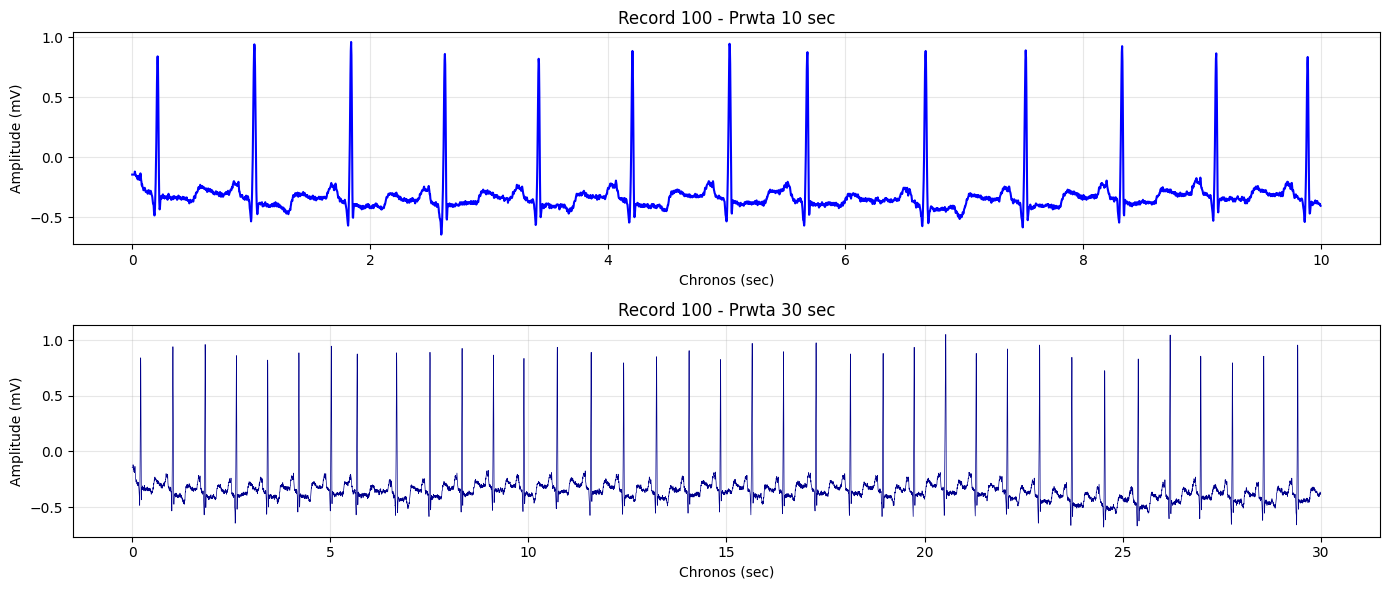

In [6]:
# PRWTH MATIA — 10 kai 30 deuterolepta

seconds = 10
samples = int(seconds * fs)
time = np.arange(samples) / fs

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(time, ecg[:samples], color='blue')
axes[0].set_title("Record " + record_id + " - Prwta 10 sec")
axes[0].set_xlabel("Chronos (sec)")
axes[0].set_ylabel("Amplitude (mV)")
axes[0].grid(True, alpha=0.3)

samples30 = int(30 * fs)
time30 = np.arange(samples30) / fs
axes[1].plot(time30, ecg[:samples30], color='darkblue', linewidth=0.5)
axes[1].set_title("Record " + record_id + " - Prwta 30 sec")
axes[1].set_xlabel("Chronos (sec)")
axes[1].set_ylabel("Amplitude (mV)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ΘΕΩΡΙΑ 4 — Θορυβος στο ECG

---

## Γιατι υπαρχει θορυβος;

Στον ιδανικο κοσμο, το ECG θα εδειχνε μονο την καρδια. 
Στην πραξη ομως, τα ηλεκτροδια "ακουν" πολλα σηματα ταυτοχρονα. 
Αυτα ονομαζονται artefacts ή θορυβος.

## Τυπος 1: Baseline Wander (κατω απο 0.5 Hz)

Αργη, κυματιστη μετατοπιση ολης της γραμμης βασης.

Αιτιες: αναπνοη, κινηση σωματος, κακη επαφη ηλεκτροδιου.

Λυση: High-pass filter πανω απο 0.5 Hz.

## Τυπος 2: Powerline Noise (ακριβως 50 Hz)

Γρηγορη, κανονικη ταλαντωση απο ηλεκτρικο δικτυο.

Αιτιες: πριζες, καλωδια, λαμπες κοντα στον ασθενη.

Λυση: Notch filter στα 50 Hz ή low-pass κατω απο 50 Hz.

## Τυπος 3: Muscle Noise / EMG (πανω απο 40 Hz)

Ακανονιστος, γρηγορος θορυβος απο μυικη δραστηριοτητα.

Αιτιες: κινηση, τρεμουλο, μασημα.

Λυση: Low-pass filter κατω απο 40 Hz.

## Η συνδυαστικη λυση

Bandpass filter 0.5-40 Hz:
- Κατω απο 0.5 Hz: αφαιρειται (drift)
- 0.5-40 Hz: κρατιεται (χρησιμο ECG)
- Πανω απο 40 Hz: αφαιρειται (noise)

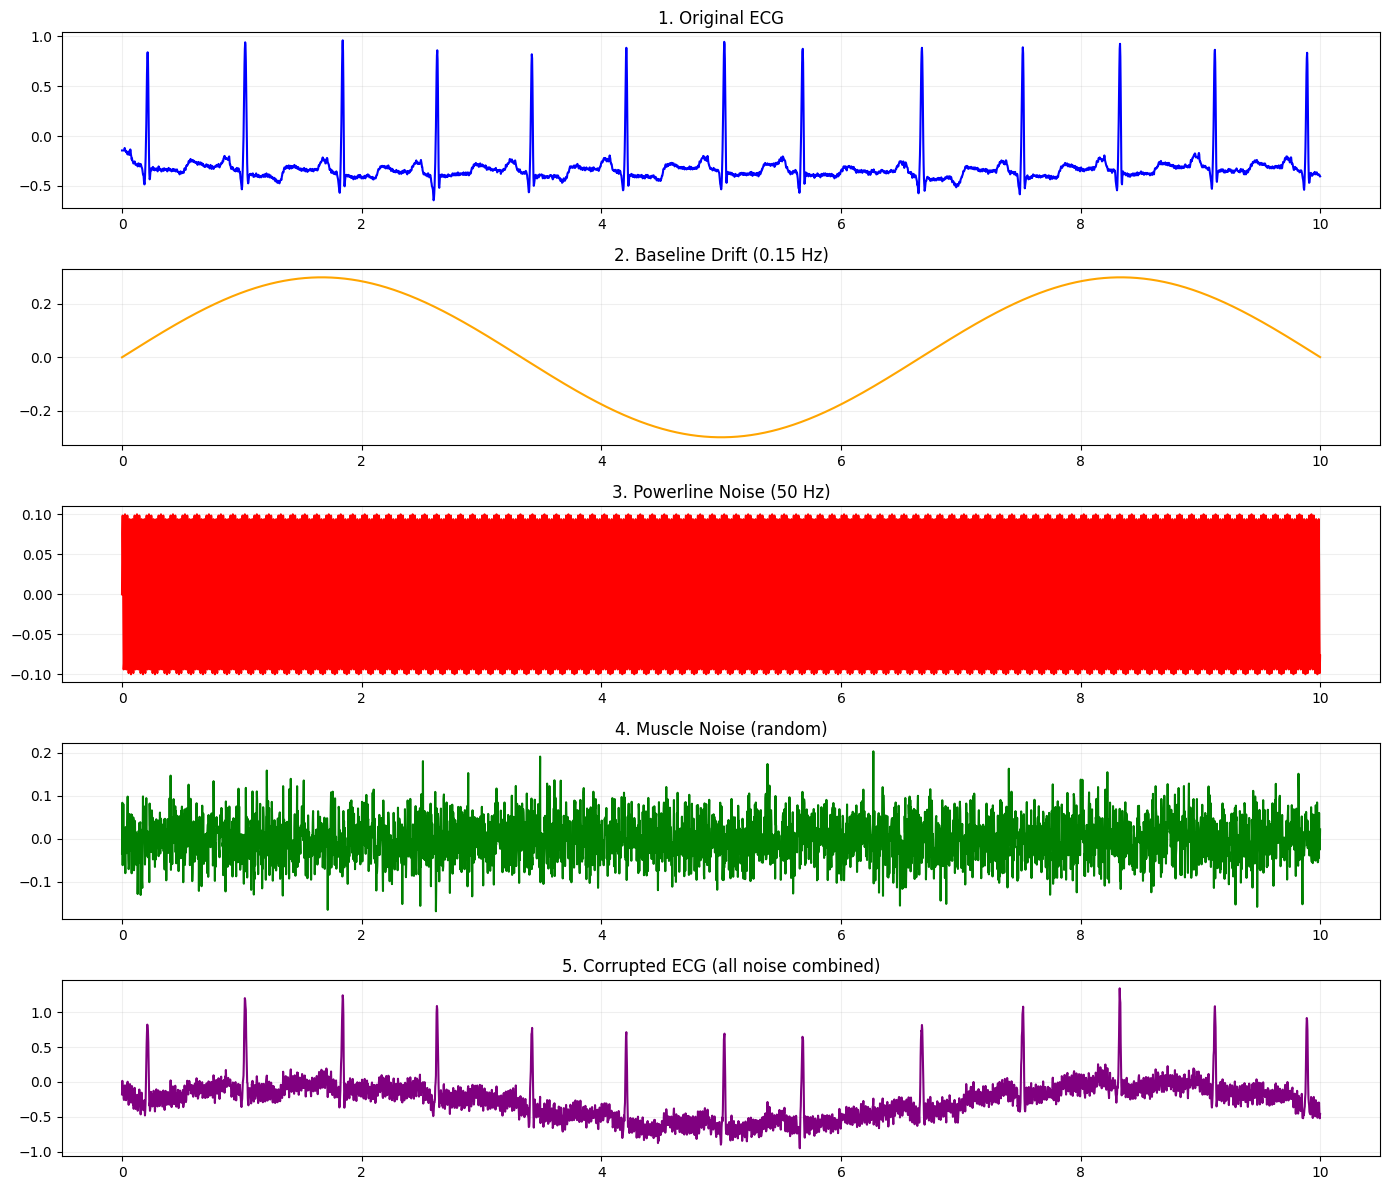

In [7]:
# ΔΗΜΙΟΥΡΓΙΑ ΤΕΧΝΗΤΟΥ ΘΟΡΥΒΟΥ

t = np.arange(len(ecg)) / fs

baseline_drift = 0.3 * np.sin(2 * np.pi * 0.15 * t)
powerline = 0.1 * np.sin(2 * np.pi * 50 * t)
muscle_noise = np.random.normal(0, 0.05, len(ecg))

fig, axes = plt.subplots(5, 1, figsize=(14, 12))

axes[0].plot(time, ecg[:samples], color='blue')
axes[0].set_title("1. Original ECG")

axes[1].plot(time, baseline_drift[:samples], color='orange')
axes[1].set_title("2. Baseline Drift (0.15 Hz)")

axes[2].plot(time, powerline[:samples], color='red')
axes[2].set_title("3. Powerline Noise (50 Hz)")

axes[3].plot(time, muscle_noise[:samples], color='green')
axes[3].set_title("4. Muscle Noise (random)")

corrupted_demo = ecg[:samples] + baseline_drift[:samples] + powerline[:samples] + muscle_noise[:samples]
axes[4].plot(time, corrupted_demo, color='purple')
axes[4].set_title("5. Corrupted ECG (all noise combined)")

for ax in axes:
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# ΑΣΚΗΣΗ 1 — Κατανοηση Θορυβου
---

## Στοχος
Να κατανοησετε πως ο θορυβος επηρεαζει το ECG 
και ποιος τυπος ειναι πιο καταστροφικος.

## Οδηγιες

### Βημα 1
Δημιουργηστε corrupted ECG προσθετοντας ΟΛΑ 
τα ειδη θορυβου (baseline_drift + powerline + muscle_noise).

### Βημα 2
Σχεδιαστε Original πανω, Corrupted κατω.

### Βημα 3
Αυξηστε τα πλατη θορυβου x3 και ξανασχεδιαστε.

## Ερωτησεις
1. Μπορειτε ακομα να δειτε τα R peaks;
2. Ποιος θορυβος ειναι πιο καταστροφικος; Γιατι;
3. Αν ειχατε μονο baseline drift, θα βρισκατε 
   τα R peaks; Γιατι;

In [ ]:
# ===============================
# ΑΣΚΗΣΗ 1 — ΓΡΑΨΤΕ ΕΔΩ
# ===============================

# Βημα 1: Prostheste thoruvo
corrupted = ecg + ______ + ______ + ______

# Βημα 2: Sxediaste
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(time, ecg[:samples])
axes[0].set_title("Original")

axes[1].plot(time, corrupted[:samples])
axes[1].set_title("Corrupted")

plt.tight_layout()
plt.show()

# Βημα 3: Auxiste x3
corrupted_x3 = ecg + 3 * ______ + 3 * ______ + 3 * ______

plt.figure(figsize=(14, 4))
plt.plot(time, corrupted_x3[:samples])
plt.title("Corrupted x3")
plt.show()

# ΘΕΩΡΙΑ 5 — Ψηφιακο Φιλτραρισμα

---

## Τι ειναι ψηφιακο φιλτρο;

Ενα μαθηματικο εργαλειο που επιτρεπει ορισμενες 
συχνοτητες να περασουν ενω μπλοκαρει αλλες.

## Τυποι φιλτρων

### Low-pass: κραταει χαμηλες, κοβει υψηλες
### High-pass: κραταει υψηλες, κοβει χαμηλες
### Bandpass: κραταει ενα ευρος (π.χ. 0.5-40 Hz)
### Notch: κοβει ακριβως μια συχνοτητα (π.χ. 50 Hz)

## Butterworth Filter

Ομαλη αποκριση, χωρις κυματισμους. 
Ταξη 4 ειναι καλη επιλογη για ECG.

## Τι ειναι filtfilt;

Εφαρμοζει το φιλτρο δυο φορες (μπροστα + πισω) 
ωστε τα peaks να μην μετατοπιστουν χρονικα.

# ΑΣΚΗΣΗ 2 — Φιλτραρισμα

---

## Στοχος
Να κατανοησετε πως η επιλογη συχνοτητων φιλτρου 
επηρεαζει την ποιοτητα του σηματος.

## Οδηγιες

### Δοκιμαστε 3 διαφορετικα ευρη:

| Δοκιμη | Low | High | Τι περιμενουμε |
|--------|-----|------|----------------|
| A | 1 Hz | 20 Hz | Χανει μερος QRS |
| B | 0.5 Hz | 40 Hz | Βελτιστο |
| C | 5 Hz | 50 Hz | Κραταει powerline |

## Ερωτησεις
1. Ποιο ευρος δινει καλυτερο αποτελεσμα; Γιατι;
2. Στη δοκιμη A, τι αλλαζει στο QRS;
3. Στη δοκιμη C, γιατι υπαρχει ακομα θορυβος;

In [ ]:
# ===============================
# ΑΣΚΗΣΗ 2 — ΓΡΑΨΤΕ ΕΔΩ
# ===============================

# Dokimi A: 1-20 Hz
b_a, a_a = signal.butter(4, [______, ______], btype='bandpass', fs=fs)
filt_a = signal.filtfilt(b_a, a_a, corrupted)

# Dokimi B: 0.5-40 Hz
b_b, a_b = signal.butter(4, [______, ______], btype='bandpass', fs=fs)
filt_b = signal.filtfilt(b_b, a_b, corrupted)

# Dokimi C: 5-50 Hz
b_c, a_c = signal.butter(4, [______, ______], btype='bandpass', fs=fs)
filt_c = signal.filtfilt(b_c, a_c, corrupted)

# SXEDIASTE
fig, axes = plt.subplots(5, 1, figsize=(14, 14))

axes[0].plot(time, ecg[:samples])
axes[0].set_title("Original")

axes[1].plot(time, corrupted[:samples])
axes[1].set_title("Corrupted")

axes[2].plot(time, filt_a[:samples])
axes[2].set_title("Filter A: 1-20 Hz")

axes[3].plot(time, filt_b[:samples])
axes[3].set_title("Filter B: 0.5-40 Hz")

axes[4].plot(time, filt_c[:samples])
axes[4].set_title("Filter C: 5-50 Hz")

for ax in axes:
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# ΘΕΩΡΙΑ 6 — Ανιχνευση R Peak

---

## Γιατι τα R peaks;

Ειναι τα πιο υψηλα και αιχμηρα σημεια του ECG, 
αρα τα πιο ευκολα να εντοπιστουν αλγοριθμικα.

## Δυο κρισιμες παραμετροι

### 1. distance (ελαχιστη αποσταση σε samples)
Η καρδια δεν μπορει να χτυπησει πιο γρηγορα 
απο καποιο οριο. Αρα δυο peaks δεν μπορουν 
να ειναι πολυ κοντα.

- Max HR 200 bpm --> distance = fs * 0.3
- Max HR 100 bpm --> distance = fs * 0.6

Πολυ μικρο distance: βρισκει ψευτικα peaks
Πολυ μεγαλο distance: χανει πραγματικα peaks

### 2. height (ελαχιστο υψος peak)
Πολυ χαμηλο: θορυβος = "peak" (false positive)
Πολυ υψηλο: χανει μικρα peaks (false negative)

### Καλη αρχικη τιμη:
height = mean(filtered) + 0.5 * std(filtered)

# ΑΣΚΗΣΗ 3 — Peak Detection Tuning

---

## Στοχος
Να βρειτε τον καλυτερο συνδυασμο distance/height.

## Δοκιμαστε 4 συνδυασμους:

| Δοκιμη | distance | height |
|--------|----------|--------|
| 1 | fs * 0.3 | 0.3 |
| 2 | fs * 0.6 | 0.5 |
| 3 | fs * 0.6 | auto |
| 4 | fs * 0.8 | 0.8 |

(auto = mean + 0.5*std)

## Αναμενομενο σε 10 sec (αν HR περιπου 70 bpm):
70 * 10 / 60 = περιπου 12 peaks

## Ερωτησεις
1. Ποια δοκι��η δινει πιο λογικο αριθμο;
2. Γιατι η δοκιμη 1 δινει πολλα peaks;
3. Γιατι η δοκιμη 4 μπορει να χασει peaks;

In [ ]:
# ===============================
# ΑΣΚΗΣΗ 3 — ΓΡΑΨΤΕ ΕΔΩ
# ===============================

# Filtrarismo pragmatikou simatos
b, a = signal.butter(4, [0.5, 40], btype='bandpass', fs=fs)
filtered = signal.filtfilt(b, a, ecg)

# Dokimi 1
peaks1, _ = signal.find_peaks(filtered[:samples],
                              distance=int(fs * ______),
                              height=______)

# Dokimi 2
peaks2, _ = signal.find_peaks(filtered[:samples],
                              distance=int(fs * ______),
                              height=______)

# Dokimi 3 (auto height)
auto_height = np.mean(filtered[:samples]) + 0.5 * np.std(filtered[:samples])
peaks3, _ = signal.find_peaks(filtered[:samples],
                              distance=int(fs * ______),
                              height=auto_height)

# Dokimi 4
peaks4, _ = signal.find_peaks(filtered[:samples],
                              distance=int(fs * ______),
                              height=______)

print("Dokimi 1: " + str(len(peaks1)) + " peaks")
print("Dokimi 2: " + str(len(peaks2)) + " peaks")
print("Dokimi 3: " + str(len(peaks3)) + " peaks (auto height)")
print("Dokimi 4: " + str(len(peaks4)) + " peaks")
print("")
print("Anamenomeno (~70 bpm x 10 sec / 60): ~" + str(int(70*10/60)) + " peaks")

In [ ]:
# SXEDIASTE THN KALYTERH DOKIMH

best_peaks = ______  # peaks1, peaks2, peaks3 h peaks4

plt.figure(figsize=(14, 4))
plt.plot(time, filtered[:samples], label="Filtered ECG")
plt.plot(best_peaks / fs,
         filtered[best_peaks],
         "rv", markersize=10, label="R Peaks")
plt.title("R Peak Detection - Record " + record_id)
plt.xlabel("Chronos (sec)")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# PLHRES PEAK DETECTION SE OLO TO SHMA

auto_height_full = np.mean(filtered) + 0.5 * np.std(filtered)
all_peaks, _ = signal.find_peaks(filtered,
                                  distance=int(fs * 0.6),
                                  height=auto_height_full)

print("Synolo R peaks: " + str(len(all_peaks)))
expected = int(len(ecg) / fs * 70 / 60)
print("Anamenomeno (~70 bpm): ~" + str(expected))

# ΑΣΚΗΣΗ 4 — Υπολογισμος Heart Rate

---

## Οδηγιες

### Βημα 1: Υπολογιστε RR intervals
Χρησιμοποιηστε np.diff(all_peaks) / fs

### Βημα 2: Μεσος HR = 60 / mean(RR)

### Βημα 3: Χαρακτηρισμος
- Κατω απο 60: Βραδυκαρδια
- 60-100: Φυσιολογικο
- Πανω απο 100: Ταχυκαρδια

### Βημα 4: Σχεδιαστε Instantaneous HR

## Ερωτησεις
1. Ο ρυθμος ειναι σταθερος ή μεταβαλλεται;
2. Υπαρχουν ξαφνικα "πηδηματα"; Τι σημαινουν;

In [ ]:
# ===============================
# ΑΣΚΗΣΗ 4 — ΓΡΑΨΤΕ ΕΔΩ
# ===============================

rr = np.diff(______) / fs

hr_mean = 60 / np.______(rr)

print("Mesos HR: " + str(round(hr_mean, 1)) + " bpm")
print("Min HR: " + str(round(60 / np.max(rr), 1)) + " bpm")
print("Max HR: " + str(round(60 / np.min(rr), 1)) + " bpm")

if hr_mean < 60:
    print("-- Bradycardia")
elif hr_mean > 100:
    print("-- Tachycardia")
else:
    print("-- Fysiologikos rythmos")

# Instantaneous HR
instant_hr = 60 / rr

plt.figure(figsize=(12, 4))
plt.plot(instant_hr[:200], marker='.', markersize=2, linewidth=0.5)
plt.title("Instantaneous HR - Record " + record_id)
plt.ylabel("BPM")
plt.xlabel("Beat Number")
plt.axhline(y=60, color='g', linestyle='--', alpha=0.5, label='60 bpm')
plt.axhline(y=100, color='r', linestyle='--', alpha=0.5, label='100 bpm')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# ΑΣΚΗΣΗ 5 — Tachogram και Histogram

---

## Τι ειναι Tachogram;
Γραφημα RR intervals στη σειρα (beat number vs RR).
- Σταθερο: κανονικος ρυθμος
- Μεταβλητο: HRV ή αρρυθμια

## Τι ειναι RR Histogram;
Δειχνει ποσο συχνα εμφανιζεται καθε τιμη RR.
- Στενο: σταθερος ρυθμος
- Πλατυ: μεγαλη μεταβλητοτητα
- 2 κορυφες: πιθανον 2 ειδη beats

## Ερωτησεις
1. Η κατανομη εχει 1 ή 2 κορυφες;
2. Υπαρχουν outliers;
3. Τι σημαινουν κλινικα;

In [ ]:
# ===============================
# ΑΣΚΗΣΗ 5 — ΓΡΑΨΤΕ ΕΔΩ
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rr[:200], marker='.', markersize=3, linewidth=0.5)
axes[0].set_title("Tachogram - Record " + record_id)
axes[0].set_ylabel("RR (sec)")
axes[0].set_xlabel("Beat Number")
axes[0].axhline(y=np.mean(rr), color='r', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.2)

axes[1].hist(rr, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title("RR Distribution - Record " + record_id)
axes[1].set_xlabel("RR (sec)")
axes[1].set_ylabel("Count")
axes[1].axvline(x=np.mean(rr), color='r', linestyle='--', label='Mean RR')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Mean RR: " + str(round(np.mean(rr), 3)) + " sec")
print("Std RR:  " + str(round(np.std(rr), 3)) + " sec")
print("Min RR:  " + str(round(np.min(rr), 3)) + " sec")
print("Max RR:  " + str(round(np.max(rr), 3)) + " sec")

# ΘΕΩΡΙΑ 7 — Heart Rate Variability (HRV)

---

## Η καρδια ΔΕΝ ειναι μετρονομος

Μια υγιης καρδια εχει μεταβλητοτητα στον ρυθμο.

## Αυτονομο Νευρικο Συστημα (ANS)

- Συμπαθητικο: επιταχυνει (στρες, ασκηση)
- Παρασυμπαθητικο: επιβραδυνει (ηρεμια, υπνος)

## SDNN = τυπικη αποκλιση RR
- Συνολικη μεταβλητοτητα
- Πανω απο 100 ms: υγιες
- Κατω απο 50 ms: μειωμενο

## RMSSD = ριζα μεσου τετραγωνου διαδοχικων διαφορων
- Βραχυπροθεσμες αλλαγες
- Αντανακλα κυριως παρασυμπαθητικο

## ΠΡΟΣΟΧΗ
Υψηλο SDNN λογω αρρυθμιων ΔΕΝ ειναι υγιες HRV!

# ΑΣΚΗΣΗ 6 — HRV Time Domain

---

## Οδηγιες

### Βημα 1: SDNN = np.std(rr) (x1000 για ms)
### Βημα 2: RMSSD = np.sqrt(np.mean(np.diff(rr)**2)) (x1000 για ms)
### Βημα 3: Σημειωστε στον πινακα ολων των ομαδων

| Ομαδα | Record | HR | SDNN (ms) | RMSSD (ms) |
|-------|--------|----|-----------|------------|
| A | 100 | | | |
| B | 106 | | | |
| C | 119 | | | |

## Ερωτησεις
1. Ποιο record εχει μεγαλυτερο SDNN;
2. Ειναι αυτο "υγιες" ή λογω αρρυθμιων;

In [ ]:
# ===============================
# ΑΣΚΗΣΗ 6 — ΓΡΑΨΤΕ ΕΔΩ
# ===============================

sdnn = np.______(rr)
rmssd = np.sqrt(np.mean(np.diff(rr) ** ______))

print("=" * 40)
print("HRV - Record " + record_id)
print("=" * 40)
print("SDNN:  " + str(round(sdnn * 1000, 1)) + " ms")
print("RMSSD: " + str(round(rmssd * 1000, 1)) + " ms")
print("HR:    " + str(round(hr_mean, 1)) + " bpm")
print("=" * 40)

if sdnn * 1000 > 100:
    print("-- Ypshlh metavlhtothta")
elif sdnn * 1000 > 50:
    print("-- Metria metavlhtothta")
else:
    print("-- Xamhlh metavlhtothta")

# ΘΕΩΡΙΑ 8 — Τυποι Καρδιακων Παλμων

---

## MIT-BIH Annotations

| Συμβολο | Ονομασια | Σημασια |
|---------|----------|---------|
| N | Normal | Φυσιολογικος παλμος |
| V | PVC | Πρωιμη Κοιλιακη Συστολη |
| A | APC | Πρωιμη Κολπικη Συστολη |
| / | Paced | Βηματοδοτουμενος |

## Τι ειναι PVC;

Παλμος που ξεκιναει μεσα στην κοιλια, χωρις σημα 
απο τον SA node.

Χαρακτηριστικα:
1. Πρωιμος (μικρο RR πριν)
2. Αντισταθμιστικη παυση (μεγαλο RR μετα)
3. Πλατυ QRS (πανω απο 120 ms)
4. Διαφορετικη μορφολογια

# ΑΣΚΗΣΗ 7 — Αναλυση Beat Types

---

## Οδηγιες
1. Βρειτε ολους τους τυπους beats (Counter)
2. Μετρηστε Normal vs PVC
3. Υπολογιστε PVC% = PVC/Total * 100
4. Σχεδιαστε bar chart

## Ερωτησεις
1. Ποσο % ειναι PVC; (κατω απο 1% = φυσιολογικο)
2. Ποια ομαδα εχει τα περισσοτερα;

In [ ]:
# ===============================
# ΑΣΚΗΣΗ 7 — ΓΡΑΨΤΕ ΕΔΩ
# ===============================

counts = Counter(annotation.symbol)
total = sum(counts.values())
normal = counts.get('N', 0)
pvc = counts.get('V', 0)
pvc_pct = (pvc / total) * 100

print("Beat Types - Record " + record_id)
print("Total: " + str(total))
print("Normal (N): " + str(normal) + " (" + str(round(normal / total * 100, 1)) + "%)")
print("PVC (V): " + str(pvc) + " (" + str(round(pvc_pct, 1)) + "%)")
print("Other: " + str(total - normal - pvc))

# Bar chart
top_types = dict(counts.most_common(6))
colors = []
for label in top_types.keys():
    if label == 'V':
        colors.append('red')
    elif label == 'N':
        colors.append('green')
    else:
        colors.append('steelblue')

plt.figure(figsize=(8, 4))
plt.bar(top_types.keys(), top_types.values(), color=colors, edgecolor='black')
plt.title("Beat Distribution - Record " + record_id)
plt.ylabel("Count")
plt.show()

# ΑΣΚΗΣΗ 8 — Μορφολογια Beats

---

## Στοχος
Να δειτε πως μοιαζουν Normal vs PVC beats.

## Οδηγιες
1. Κοψτε παραθυρα +/- 0.3 sec γυρω απο καθε beat
2. Σχεδιαστε 5 Normal beats μαζι (overlay)
3. Σχεδιαστε 5 PVC beats μαζι (αν υπαρχουν)
4. Σχεδιαστε average Normal vs average PVC

## Ερωτησεις
1. Γραψτε 3 διαφορες μορφολογιας
2. Ποιο beat εχει πλατυτερο QRS;
3. Ποιο εχει μεγαλυτερο amplitude;

In [ ]:
# ===============================
# ΑΣΚΗΣΗ 8 — ΓΡΑΨΤΕ ΕΔΩ
# ===============================

window = int(0.3 * fs)
ann_samples = annotation.sample
ann_symbols = annotation.symbol

normal_beats = []
pvc_beats = []

for i in range(len(ann_samples)):
    peak = ann_samples[i]
    if peak - window > 0 and peak + window < len(filtered):
        beat = filtered[peak - window : peak + window]
        if ann_symbols[i] == 'N' and len(normal_beats) < 20:
            normal_beats.append(beat)
        elif ann_symbols[i] == 'V' and len(pvc_beats) < 20:
            pvc_beats.append(beat)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for beat in normal_beats[:5]:
    axes[0].plot(beat, alpha=0.5)
axes[0].set_title("Normal Beats (overlay)")

if len(pvc_beats) > 0:
    for beat in pvc_beats[:5]:
        axes[1].plot(beat, alpha=0.5, color='red')
    axes[1].set_title("PVC Beats (overlay)")
else:
    axes[1].text(0.5, 0.5, "No PVC found",
                 ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title("PVC Beats")

avg_normal = np.mean(normal_beats, axis=0)
axes[2].plot(avg_normal, label="Avg Normal", color='blue', linewidth=2)
if len(pvc_beats) > 0:
    avg_pvc = np.mean(pvc_beats, axis=0)
    axes[2].plot(avg_pvc, label="Avg PVC", color='red', linewidth=2)
axes[2].set_title("Average Beat Comparison")
axes[2].legend()

plt.suptitle("Beat Morphology - Record " + record_id, fontsize=14)
plt.tight_layout()
plt.show()

# ΑΣΚΗΣΗ 9 — Normal vs PVC RR Analysis

---

## Υπενθυμιση θεωριας
- RR ΠΡΙΝ PVC: μικροτερο (πρωιμος παλμος)
- RR ΜΕΤΑ PVC: μεγαλυτερο (αντισταθμιστικη παυση)

## Οδηγιες
1. Χωριστε RR σε Normal και PVC
2. Σχεδιαστε histogram μαζι
3. Υπολογιστε μεσο RR καθε κατηγοριας

## Ερωτησεις
1. Τα PVC RR ειναι μικροτερα ή μεγαλυτερα;
2. Ταιριαζει με τη θεωρια; Εξηγηστε.

In [ ]:
# ===============================
# ΑΣΚΗΣΗ 9 — ΓΡΑΨΤΕ ΕΔΩ
# ===============================

rr_ann = []
beat_labels = []

for i in range(1, len(ann_samples)):
    rr_val = (ann_samples[i] - ann_samples[i - 1]) / fs
    rr_ann.append(rr_val)
    beat_labels.append(ann_symbols[i])

normal_rr = [rr_ann[i] for i in range(len(beat_labels))
             if beat_labels[i] == 'N']
pvc_rr = [rr_ann[i] for i in range(len(beat_labels))
           if beat_labels[i] == 'V']

print("Normal: n=" + str(len(normal_rr)) + ", mean=" + str(round(np.mean(normal_rr), 3)) + " sec")
if len(pvc_rr) > 0:
    print("PVC:    n=" + str(len(pvc_rr)) + ", mean=" + str(round(np.mean(pvc_rr), 3)) + " sec")

plt.figure(figsize=(10, 4))
plt.hist(normal_rr, bins=50, alpha=0.5,
         label="Normal (n=" + str(len(normal_rr)) + ")", color='blue')
if len(pvc_rr) > 0:
    plt.hist(pvc_rr, bins=50, alpha=0.5,
             label="PVC (n=" + str(len(pvc_rr)) + ")", color='red')
plt.legend()
plt.title("RR Distribution by Beat Type - Record " + record_id)
plt.xlabel("RR (sec)")
plt.ylabel("Count")
plt.show()

# ΘΕΩΡΙΑ 9 — Ανιχνευση Αρρυθμιων (Rule-Based)

---

## Βασικη ιδεα
Αν ενα RR interval αποκλινει πολυ απο τον μεσο ορο, 
τοτε ο αντιστοιχος παλμος ειναι "υποπτος".

## Κανονας
|RR - mean(RR)| > k * std(RR)

## Τιμες k

| k | Ευαισθησια | False Positives |
|---|-----------|-----------------|
| 1.5 | Υψηλη | Πολλα |
| 2.0 | Μετρια | Μετρια |
| 2.5 | Χαμηλη | Λιγα |

## Περιορισμοι
- Δεν εξεταζει μορφολογια QRS
- Δεν ξεχωριζει τυπο αρρυθμιας
- False positives σε φυσιολογικη μεταβλητοτητα

# ΑΣΚΗΣΗ 10 — Rule-Based Arrhythmia Detector

---

## Οδηγιες
1. Υπολογιστε mean και std των RR
2. Εφαρμοστε κανονα για k = 1.5, 2.0, 2.5
3. Συγκρινετε με πραγματικο αριθμο PVC

## Ερωτησεις
1. Ποιο k πλησιαζει τα πραγματικα PVC;
2. Γιατι δεν ταιριαζει ακριβως;
3. Τι θα βελτιωνατε;

In [ ]:
# ===============================
# ΑΣΚΗΣΗ 10 — ΓΡΑΨΤΕ ΕΔΩ
# ===============================

rr_mean_ann = np.mean(rr_ann)
rr_std_ann = np.std(rr_ann)

print("Mean RR: " + str(round(rr_mean_ann, 3)) + " sec")
print("Std RR:  " + str(round(rr_std_ann, 3)) + " sec")
print("Real PVC count: " + str(pvc))
print("")

for k in [1.5, 2.0, 2.5]:
    suspicious = sum(1 for r in rr_ann
                     if abs(r - rr_mean_ann) > k * rr_std_ann)
    pct = round(suspicious / len(rr_ann) * 100, 1)
    print("k=" + str(k) + ": " + str(suspicious) + " ypopta (" + str(pct) + "%) | Pragmatika PVC: " + str(pvc))

# ΤΕΛΙΚΗ ΣΥΓΚΡΙΣΗ ΟΜΑΔΩΝ

---

## Γραψτε τα αποτελεσματα στον πινακα:

| Μετρηση | Ομαδα A (100) | Ομαδα B (106) | Ομαδα C (119) |
|---------|---------------|---------------|---------------|
| HR (bpm) | | | |
| SDNN (ms) | | | |
| RMSSD (ms) | | | |
| Total beats | | | |
| PVC count | | | |
| PVC % | | | |
| Ypopta k=2 | | | |

## Ερωτησεις Συζητησης

1. Ποιο record ειναι πιο "υγιες"; Γιατι;
2. Ποιο εχει υψηλοτερο HRV; Ειναι υγιες ή λογω αρρυθμιων;
3. Υπαρχει σχεση PVC% και SDNN;
4. Ο rule-based detector ειναι αξιοπιστος;
5. Τι θα βελτιωνατε;

In [ ]:
# TELIKH ANAFORA OMADAS

print("=" * 60)
print("TELIKH ANAFORA - OMADA: Record " + record_id)
print("=" * 60)
print("  HR:          " + str(round(hr_mean, 1)) + " bpm")
print("  SDNN:        " + str(round(sdnn * 1000, 1)) + " ms")
print("  RMSSD:       " + str(round(rmssd * 1000, 1)) + " ms")
print("  Total beats: " + str(total))
print("  Normal (N):  " + str(normal) + " (" + str(round(normal / total * 100, 1)) + "%)")
print("  PVC (V):     " + str(pvc) + " (" + str(round(pvc_pct, 1)) + "%)")
print("=" * 60)

# BONUS — Frequency Domain HRV

---

## Ιδεα
Εφαρμοζουμε FFT στα RR intervals.

## Μπαντες

| Μπαντα | Ευρος | Σχετιζεται με |
|--------|-------|---------------|
| LF | 0.04-0.15 Hz | Μικτο (συμπαθητικο + παρασυμπαθητικο) |
| HF | 0.15-0.40 Hz | Παρασυμπαθητικο (αναπνοη) |

## LF/HF Ratio
- Υψηλο: συμπαθητικη κυριαρχια (στρες)
- Χαμηλο: παρασυμπαθητικη κυριαρχια (χαλαρωση)

In [ ]:
# BONUS - Frequency HRV

from scipy.interpolate import interp1d

rr_times = np.cumsum(rr_ann)
rr_values = np.array(rr_ann)

fs_hrv = 4
t_interp = np.arange(rr_times[0], rr_times[-1], 1.0 / fs_hrv)
interp_func = interp1d(rr_times, rr_values, kind='cubic')
rr_interp = interp_func(t_interp)

rr_centered = rr_interp - np.mean(rr_interp)

N_fft = len(rr_centered)
yf = np.abs(fft(rr_centered)) ** 2
xf = fftfreq(N_fft, 1.0 / fs_hrv)

mask = (xf > 0) & (xf < 0.5)

plt.figure(figsize=(12, 5))
plt.plot(xf[mask], yf[mask])
plt.axvspan(0.04, 0.15, alpha=0.2, color='blue', label='LF (0.04-0.15)')
plt.axvspan(0.15, 0.40, alpha=0.2, color='green', label='HF (0.15-0.40)')
plt.title("HRV Power Spectrum - Record " + record_id)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

lf_mask = (xf > 0.04) & (xf < 0.15)
hf_mask = (xf > 0.15) & (xf < 0.40)

lf_power = np.sum(yf[lf_mask])
hf_power = np.sum(yf[hf_mask])

print("LF power:  " + str(round(lf_power, 2)))
print("HF power:  " + str(round(hf_power, 2)))
if hf_power > 0:
    print("LF/HF:    " + str(round(lf_power / hf_power, 2)))

# BONUS — Mikro ML Classification

---

## Στοχος
Logistic Regression: Normal vs PVC βαση RR intervals.

## Features: RR_before, RR_current, RR_after
## Label: 0=Normal, 1=PVC

In [ ]:
# BONUS - Simple ML Classification

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report

X = []
y = []

for i in range(1, len(rr_ann) - 1):
    if beat_labels[i] in ['N', 'V']:
        rr_before = rr_ann[i - 1]
        rr_current = rr_ann[i]
        rr_after = rr_ann[i + 1] if i + 1 < len(rr_ann) else rr_ann[i]
        X.append([rr_before, rr_current, rr_after])
        y.append(1 if beat_labels[i] == 'V' else 0)

X = np.array(X)
y = np.array(y)

print("Total samples: " + str(len(y)))
print("Normal: " + str(sum(y == 0)))
print("PVC:    " + str(sum(y == 1)))

model = LogisticRegression(max_iter=1000)
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print("")
print("5-fold CV Accuracy: " + str(round(scores.mean() * 100, 1)) + "% +/- " + str(round(scores.std() * 100, 1)) + "%")

model.fit(X, y)
y_pred = model.predict(X)

print("")
print("Classification Report:")
print(classification_report(y, y_pred, target_names=['Normal', 'PVC']))